In [ ]:
ENV = 'colab'
SEQ_COL   = 'sequence'
LABEL_COL = 'label'
N_SAMPLE  = 200

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from itertools import product
from scipy.stats import mannwhitneyu, entropy as sp_entropy
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline

!pip install statsmodels -q
from statsmodels.stats.multitest import multipletests

from google.colab import drive
drive.mount('/content/drive', force_remount=False)
DATASET_PATH = '/content/drive/MyDrive/project-finetuned/sequences_dataset.csv'

print(f'Dataset exists: {os.path.exists(DATASET_PATH)}')

Mounted at /content/drive
Dataset exists: True


In [ ]:
df = pd.read_csv(DATASET_PATH)
print(f'Total sequences: {len(df)}')
print(f'Label distribution:\n{df[LABEL_COL].value_counts()}')
print(f'\nSequence lengths: {df[SEQ_COL].str.len().describe()}')

Total sequences: 9995
Label distribution:
label
1    4999
0    4996
Name: count, dtype: int64

Sequence lengths: count    9995.0
mean      513.0
std         0.0
min       513.0
25%       513.0
50%       513.0
75%       513.0
max       513.0
Name: sequence, dtype: float64


Cell 3 — Load model and get correctly classified sequences

In [ ]:
import torch, torch.nn as nn, shutil
from transformers import AutoTokenizer, AutoConfig, AutoModel
from transformers.modeling_outputs import SequenceClassifierOutput

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

WEIGHT_FILE = '/content/drive/MyDrive/project-finetuned/dna_classifier.pt'

# ── Patch bert_layers.py ──────────────────────────────────────────────────────
cache_dir   = os.path.expanduser('~/.cache/huggingface/modules/transformers_modules')
layers_file = None
for root, dirs, files in os.walk(cache_dir):
    for f in files:
        if f == 'bert_layers.py':
            layers_file = os.path.join(root, f)
            break

if layers_file:
    with open(layers_file, 'r') as f:
        lines = f.readlines()
    new_lines = []
    for i, line in enumerate(lines):
        if i+1 == 29 and 'flash_attn_triton' in line:
            new_lines.append('    flash_attn_qkvpacked_func = None  # disabled\n')
        elif 'if flash_attn_qkvpacked_func is not None' in line:
            new_lines.append(line.replace(
                'if flash_attn_qkvpacked_func is not None', 'if False'))
        elif 'if self.p_dropout or flash_attn_qkvpacked_func is None' in line:
            new_lines.append('        if True:  # flash_attn disabled\n')
        else:
            new_lines.append(line)
    with open(layers_file, 'w') as f:
        f.writelines(new_lines)
    triton_cache = os.path.expanduser('~/.triton/cache')
    if os.path.exists(triton_cache):
        shutil.rmtree(triton_cache)
    mods = [k for k in sys.modules if any(x in k for x in
            ['DNABERT','bert_layers','flash_attn','transformers_modules'])]
    for m in mods: del sys.modules[m]
    print(f'✓ Flash Attention disabled')

# ── Rebuild DNAClassifier ─────────────────────────────────────────────────────
class DNAClassifier(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone   = backbone
        self.classifier = nn.Sequential(
            nn.Linear(768, 768),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(768, 2),
        )
    def forward(self, input_ids, attention_mask=None, **kwargs):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        pooled  = (outputs.pooler_output
                   if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None
                   else outputs[1])
        return SequenceClassifierOutput(logits=self.classifier(pooled))

tokenizer = AutoTokenizer.from_pretrained('zhihan1996/DNABERT-2-117M', trust_remote_code=True)
config    = AutoConfig.from_pretrained('zhihan1996/DNABERT-2-117M', trust_remote_code=True)
config.pad_token_id = tokenizer.pad_token_id
backbone  = AutoModel.from_config(config, trust_remote_code=True)
model     = DNAClassifier(backbone)
model.load_state_dict(torch.load(WEIGHT_FILE, map_location='cpu'), strict=True)
model     = model.to(device)
model.eval()
print(f'✓ Model loaded | dtype: {next(model.parameters()).dtype}')

# ── Get predictions ───────────────────────────────────────────────────────────
def get_predictions(seqs):
    preds, confs = [], []
    with torch.no_grad():
        for seq in seqs:
            enc  = tokenizer(seq, return_tensors='pt', max_length=200,
                             padding='max_length', truncation=True)
            enc  = {k: v.to(device) for k, v in enc.items()}
            prob = torch.softmax(model(**enc).logits, dim=-1)[0].cpu().numpy()
            preds.append(int(np.argmax(prob)))
            confs.append(float(prob[np.argmax(prob)]))
    return preds, confs

print(f'\nRunning inference on {N_SAMPLE*2} sequences...')
path_sample = df[df[LABEL_COL]==1].sample(N_SAMPLE, random_state=42)
ben_sample  = df[df[LABEL_COL]==0].sample(N_SAMPLE, random_state=42)

path_preds, _ = get_predictions(path_sample[SEQ_COL].tolist())
ben_preds,  _ = get_predictions(ben_sample[SEQ_COL].tolist())

path_correct = path_sample[[p==1 for p in path_preds]]
ben_correct  = ben_sample[[p==0 for p in ben_preds]]

path_seqs = path_correct[SEQ_COL].tolist()
ben_seqs  = ben_correct[SEQ_COL].tolist()

n_use     = min(len(path_seqs), len(ben_seqs))
path_seqs = path_seqs[:n_use]
ben_seqs  = ben_seqs[:n_use]

print(f'Correctly classified — Pathogenic: {len(path_seqs)} | Benign: {len(ben_seqs)}')
print(f'Using {n_use} per class (balanced)')

Device: cpu
✓ Flash Attention disabled


A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNABERT-2-117M:
- flash_attn_triton.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


✓ Model loaded | dtype: torch.float32

Running inference on 400 sequences...
Correctly classified — Pathogenic: 120 | Benign: 120
Using 120 per class (balanced)


In [ ]:
import re

NUCLEOTIDES   = ['A', 'C', 'G', 'T']
DINUCLEOTIDES = [a+b for a, b in product(NUCLEOTIDES, NUCLEOTIDES)]

def extract_composition_features(seq):
    seq = seq.upper()
    n   = len(seq)
    features = {}

    counts = Counter(seq)
    for nt in NUCLEOTIDES:
        features[f'freq_{nt}'] = counts.get(nt, 0) / n

    g, c = counts.get('G', 0), counts.get('C', 0)
    a, t = counts.get('A', 0), counts.get('T', 0)
    features['GC_pct']  = (g + c) / n
    features['AT_pct']  = (a + t) / n
    features['GC_skew'] = (g - c) / (g + c + 1e-10)
    features['AT_skew'] = (a - t) / (a + t + 1e-10)

    di_counts = Counter(seq[i:i+2] for i in range(n-1))
    n_di      = n - 1
    for di in DINUCLEOTIDES:
        features[f'di_{di}'] = di_counts.get(di, 0) / n_di

    cpg_obs = di_counts.get('CG', 0) / n_di
    cpg_exp = features['freq_C'] * features['freq_G']
    features['CpG_ratio'] = cpg_obs / (cpg_exp + 1e-10)

    total_hp, max_run = 0, 0
    for nt in NUCLEOTIDES:
        runs = re.findall(f'{nt}{{4,}}', seq)
        total_hp += sum(len(r) for r in runs)
        if runs:
            max_run = max(max_run, max(len(r) for r in runs))
    features['homopolymer_frac'] = total_hp / n
    features['max_homopolymer']  = max_run

    freqs = np.array([features[f'freq_{nt}'] for nt in NUCLEOTIDES]) + 1e-10
    features['sequence_entropy'] = float(-np.sum(freqs * np.log2(freqs)))
    features['purine_frac']      = (a + g) / n
    features['pyrimidine_frac']  = (c + t) / n

    return features

print('Extracting features...')
path_features = [extract_composition_features(s) for s in path_seqs]
ben_features  = [extract_composition_features(s) for s in ben_seqs]

path_df = pd.DataFrame(path_features); path_df['label'] = 1
ben_df  = pd.DataFrame(ben_features);  ben_df['label']  = 0
feat_df = pd.concat([path_df, ben_df], ignore_index=True)

feature_cols = [c for c in feat_df.columns if c != 'label']
print(f'✓ {len(feat_df)} sequences × {len(feature_cols)} features')

Extracting features...
✓ 240 sequences × 30 features


In [ ]:
results = []
for feat in feature_cols:
    path_vals = feat_df[feat_df['label']==1][feat].values
    ben_vals  = feat_df[feat_df['label']==0][feat].values
    stat, pval = mannwhitneyu(path_vals, ben_vals, alternative='two-sided')
    n1, n2     = len(path_vals), len(ben_vals)
    effect     = 1 - (2 * stat) / (n1 * n2)
    results.append({'feature': feat, 'path_mean': path_vals.mean(),
                    'ben_mean': ben_vals.mean(), 'difference': path_vals.mean()-ben_vals.mean(),
                    'pval': pval, 'effect_size': effect})

results_df = pd.DataFrame(results).sort_values('pval')
reject, pvals_corrected, _, _ = multipletests(results_df['pval'], method='bonferroni')
results_df['pval_corrected'] = pvals_corrected
results_df['significant']    = reject

print('Top 15 features by p-value:')
print(f'{"Feature":<22} {"Path mean":>10} {"Ben mean":>10} {"Effect r":>10} {"p (raw)":>10} {"p (Bonf)":>10} Sig')
print('─' * 78)
for _, row in results_df.head(15).iterrows():
    sig = '★' if row['significant'] else ''
    print(f'{row["feature"]:<22} {row["path_mean"]:>10.4f} {row["ben_mean"]:>10.4f} '
          f'{row["effect_size"]:>10.3f} {row["pval"]:>10.4f} {row["pval_corrected"]:>10.4f} {sig}')

sig_features = results_df[results_df['significant']]['feature'].tolist()
print(f'\nSignificant after Bonferroni: {len(sig_features)}')
if sig_features:
    print(f'  {sig_features}')

Top 15 features by p-value:
Feature                 Path mean   Ben mean   Effect r    p (raw)   p (Bonf) Sig
──────────────────────────────────────────────────────────────────────────────
AT_pct                     0.5651     0.4862     -0.379     0.0000     0.0000 ★
GC_pct                     0.4349     0.5138      0.379     0.0000     0.0000 ★
di_CC                      0.0581     0.0798      0.376     0.0000     0.0000 ★
freq_T                     0.2866     0.2432     -0.370     0.0000     0.0000 ★
di_GG                      0.0569     0.0826      0.365     0.0000     0.0000 ★
di_AT                      0.0696     0.0508     -0.358     0.0000     0.0001 ★
freq_C                     0.2154     0.2544      0.357     0.0000     0.0001 ★
di_GC                      0.0487     0.0653      0.349     0.0000     0.0001 ★
di_TA                      0.0582     0.0410     -0.344     0.0000     0.0001 ★
di_TT                      0.0950     0.0688     -0.339     0.0000     0.0002 ★
freq_G     

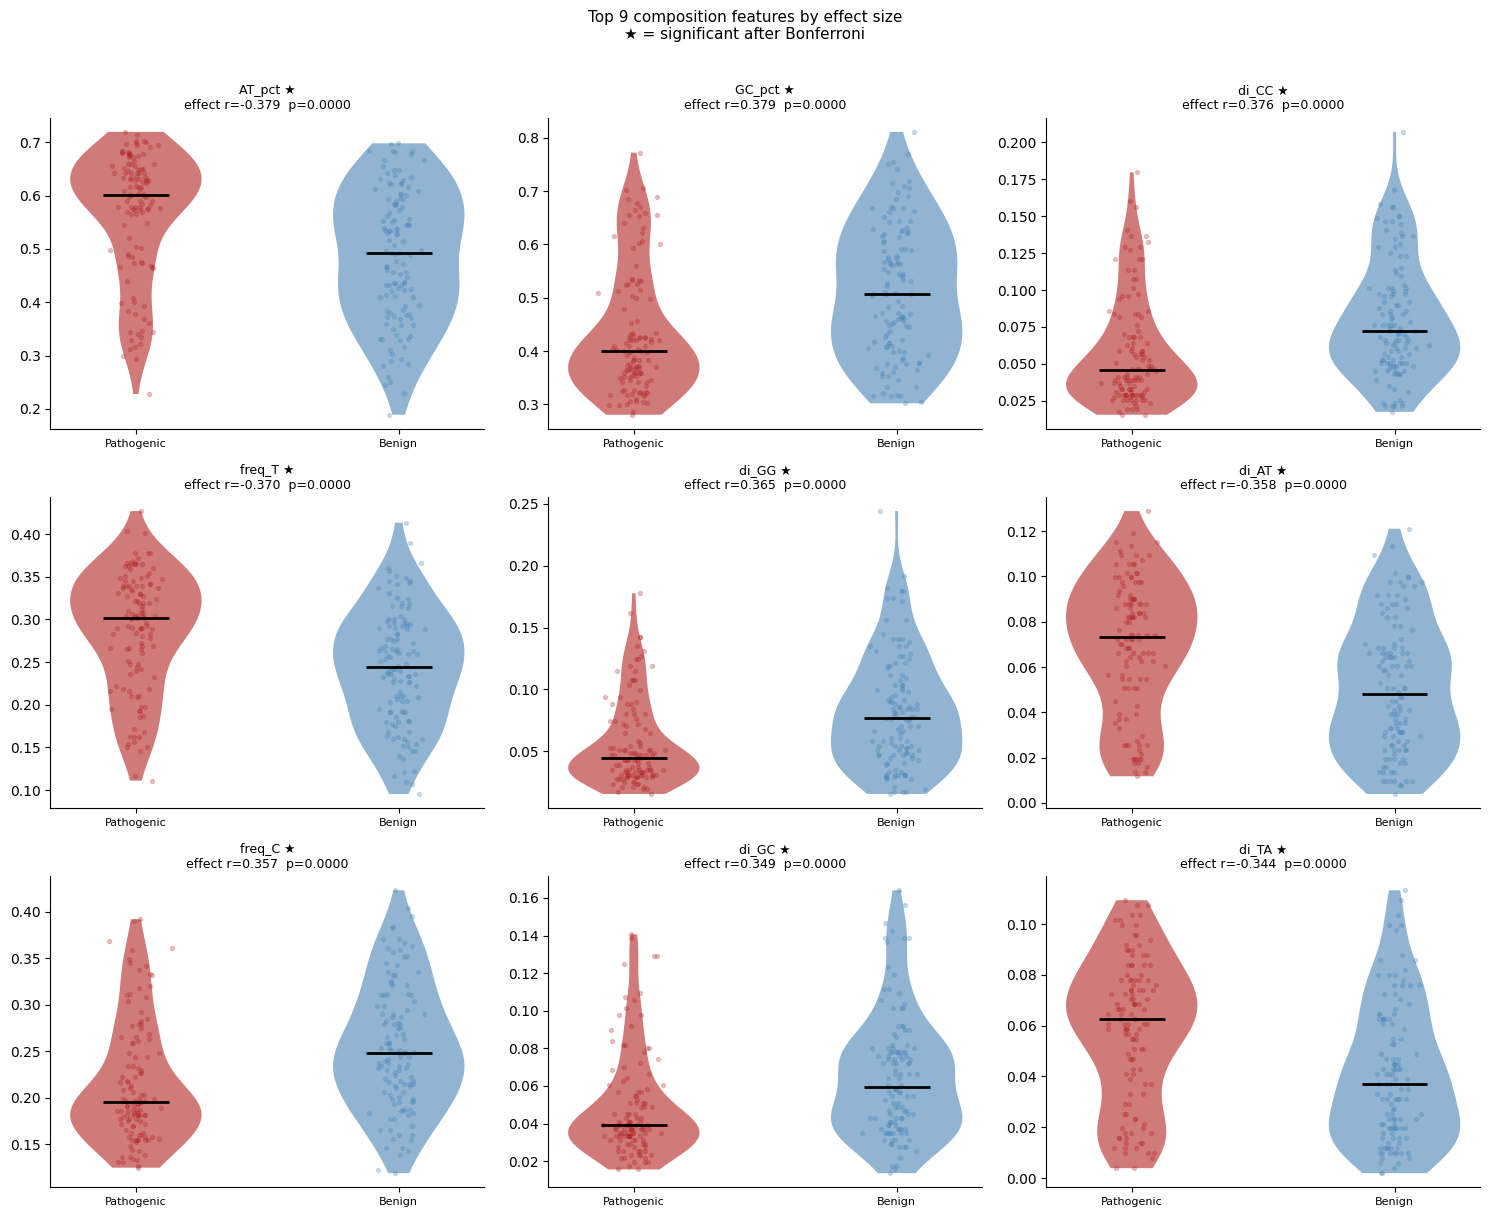

In [ ]:
top_features = results_df.reindex(
    results_df['effect_size'].abs().sort_values(ascending=False).index
).head(9)['feature'].tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    path_vals = feat_df[feat_df['label']==1][feat].values
    ben_vals  = feat_df[feat_df['label']==0][feat].values

    parts = ax.violinplot([path_vals, ben_vals], positions=[0, 1],
                          showmedians=True, showextrema=False)
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor(['firebrick','steelblue'][j]); pc.set_alpha(0.6)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)

    for j, (vals, color) in enumerate([(path_vals,'firebrick'),(ben_vals,'steelblue')]):
        jitter = np.random.normal(j, 0.04, size=len(vals))
        ax.scatter(jitter, vals, alpha=0.25, s=8, color=color)

    row = results_df[results_df['feature']==feat].iloc[0]
    ax.set_title(f'{feat}{" ★" if row["significant"] else ""}\n'
                 f'effect r={row["effect_size"]:.3f}  p={row["pval"]:.4f}', fontsize=9)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Pathogenic','Benign'], fontsize=8)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Top 9 composition features by effect size\n★ = significant after Bonferroni',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('/content/composition_features_day13.png', dpi=150, bbox_inches='tight')
plt.show()

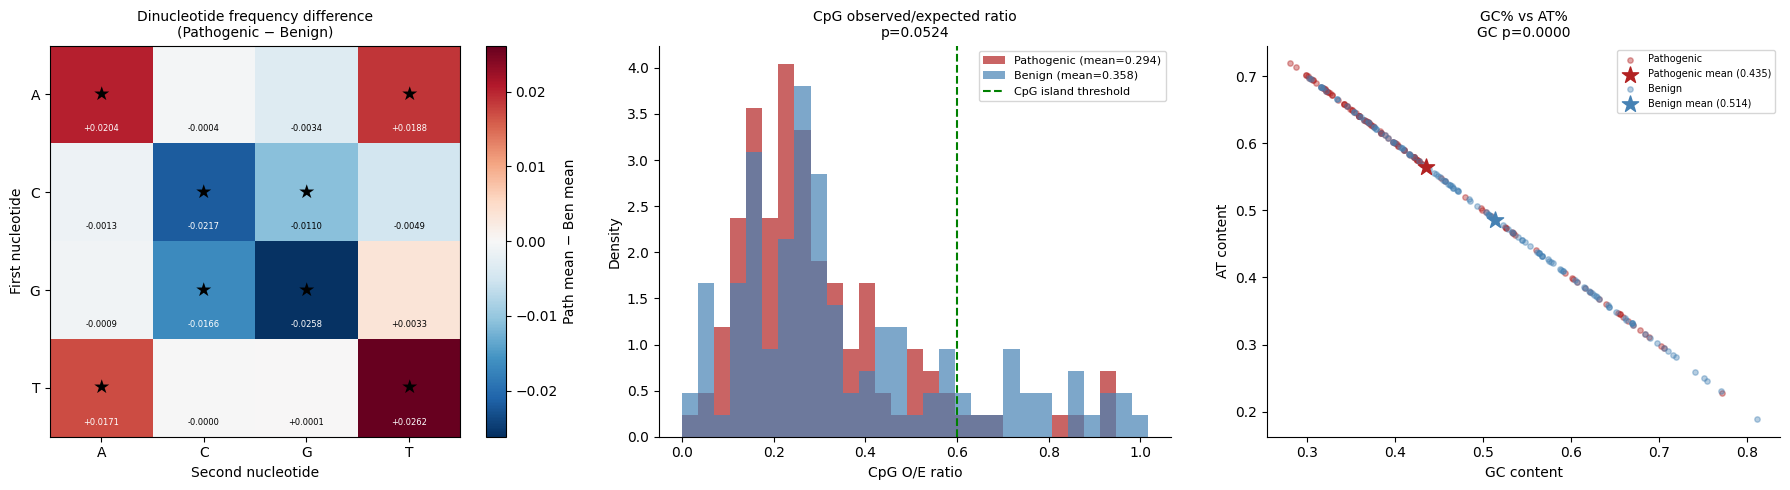

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Dinucleotide difference heatmap
ax = axes[0]
di_diff = np.zeros((4,4)); di_pval = np.zeros((4,4))
for i, nt1 in enumerate(NUCLEOTIDES):
    for j, nt2 in enumerate(NUCLEOTIDES):
        di = f'di_{nt1}{nt2}'
        pv = feat_df[feat_df['label']==1][di].values
        bv = feat_df[feat_df['label']==0][di].values
        di_diff[i,j] = pv.mean() - bv.mean()
        _, di_pval[i,j] = mannwhitneyu(pv, bv, alternative='two-sided')

vmax = np.abs(di_diff).max()
im   = ax.imshow(di_diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
plt.colorbar(im, ax=ax, label='Path mean − Ben mean')
ax.set_xticks(range(4)); ax.set_xticklabels(NUCLEOTIDES)
ax.set_yticks(range(4)); ax.set_yticklabels(NUCLEOTIDES)
ax.set_xlabel('Second nucleotide'); ax.set_ylabel('First nucleotide')
ax.set_title('Dinucleotide frequency difference\n(Pathogenic − Benign)', fontsize=10)
bonf_thresh = 0.05 / 16
for i in range(4):
    for j in range(4):
        if di_pval[i,j] < bonf_thresh:
            ax.text(j, i, '★', ha='center', va='center', fontsize=14, color='black')
        ax.text(j, i+0.35, f'{di_diff[i,j]:+.4f}', ha='center', va='center',
                fontsize=6, color='white' if abs(di_diff[i,j])>vmax*0.5 else 'black')

# CpG ratio
ax = axes[1]
path_cpg = feat_df[feat_df['label']==1]['CpG_ratio'].values
ben_cpg  = feat_df[feat_df['label']==0]['CpG_ratio'].values
bins = np.linspace(0, max(path_cpg.max(), ben_cpg.max()), 30)
ax.hist(path_cpg, bins=bins, alpha=0.7, color='firebrick',
        label=f'Pathogenic (mean={path_cpg.mean():.3f})', density=True)
ax.hist(ben_cpg,  bins=bins, alpha=0.7, color='steelblue',
        label=f'Benign (mean={ben_cpg.mean():.3f})',     density=True)
ax.axvline(0.6, color='green', linestyle='--', linewidth=1.5, label='CpG island threshold')
_, cpg_pval = mannwhitneyu(path_cpg, ben_cpg, alternative='two-sided')
ax.set_xlabel('CpG O/E ratio'); ax.set_ylabel('Density')
ax.set_title(f'CpG observed/expected ratio\np={cpg_pval:.4f}', fontsize=10)
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

# GC% vs AT% scatter
ax = axes[2]
for label, color, name in [(1,'firebrick','Pathogenic'),(0,'steelblue','Benign')]:
    gc = feat_df[feat_df['label']==label]['GC_pct'].values
    at = feat_df[feat_df['label']==label]['AT_pct'].values
    ax.scatter(gc, at, alpha=0.4, s=15, color=color, label=name)
    ax.scatter(gc.mean(), at.mean(), s=150, color=color, marker='*', zorder=5,
               label=f'{name} mean ({gc.mean():.3f})')
_, gc_pval = mannwhitneyu(feat_df[feat_df['label']==1]['GC_pct'].values,
                           feat_df[feat_df['label']==0]['GC_pct'].values,
                           alternative='two-sided')
ax.set_xlabel('GC content'); ax.set_ylabel('AT content')
ax.set_title(f'GC% vs AT%\nGC p={gc_pval:.4f}', fontsize=10)
ax.legend(fontsize=7); ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/dinucleotide_analysis_day13.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
X = feat_df[feature_cols].values
y = feat_df['label'].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gc_only_cols = ['GC_pct']
di_only_cols = [c for c in feature_cols if c.startswith('di_')]

tests = [
    ('Logistic Regression (all features)',    feature_cols),
    ('Random Forest (all features)',          feature_cols),
    ('Logistic Regression (GC% only)',        gc_only_cols),
    ('Logistic Regression (dinucleotides)',   di_only_cols),
]

clfs = [
    Pipeline([('scaler',StandardScaler()),('clf',LogisticRegression(max_iter=1000,random_state=42))]),
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    Pipeline([('scaler',StandardScaler()),('clf',LogisticRegression(max_iter=1000,random_state=42))]),
    Pipeline([('scaler',StandardScaler()),('clf',LogisticRegression(max_iter=1000,random_state=42))]),
]

print(f'{"Model":<42} {"F1":>6} {"AUC":>6} {"Acc":>6}')
print('─' * 58)
all_f1s = []
for (name, feat_subset), clf in zip(tests, clfs):
    X_sub = feat_df[feat_subset].values
    f1s   = cross_val_score(clf, X_sub, y, cv=cv, scoring='f1')
    aucs  = cross_val_score(clf, X_sub, y, cv=cv, scoring='roc_auc')
    accs  = cross_val_score(clf, X_sub, y, cv=cv, scoring='accuracy')
    print(f'{name:<42} {f1s.mean():.3f} {aucs.mean():.3f} {accs.mean():.3f}')
    all_f1s.append(f1s.mean())

print('─' * 58)
print(f'{"DNABERT-2 (Day 12 result)":<42} {"0.783":>6}')
best_f1 = max(all_f1s)
gap = 0.783 - best_f1
print(f'\nBest composition F1: {best_f1:.3f}')
print(f'Gap to DNABERT-2:    {gap:.3f}')
print()
if best_f1 >= 0.75:
    print('→ Composition explains most of what the model learned.')
elif best_f1 >= 0.60:
    print('→ Composition is a major signal but the model adds meaningful context.')
else:
    print('→ Composition alone is not enough — the model learned something beyond it.')

Model                                          F1    AUC    Acc
──────────────────────────────────────────────────────────
Logistic Regression (all features)         0.605 0.606 0.588
Random Forest (all features)               0.669 0.667 0.679
Logistic Regression (GC% only)             0.657 0.694 0.629
Logistic Regression (dinucleotides)        0.634 0.614 0.600
──────────────────────────────────────────────────────────
DNABERT-2 (Day 12 result)                   0.783

Best composition F1: 0.669
Gap to DNABERT-2:    0.114

→ Composition is a major signal but the model adds meaningful context.


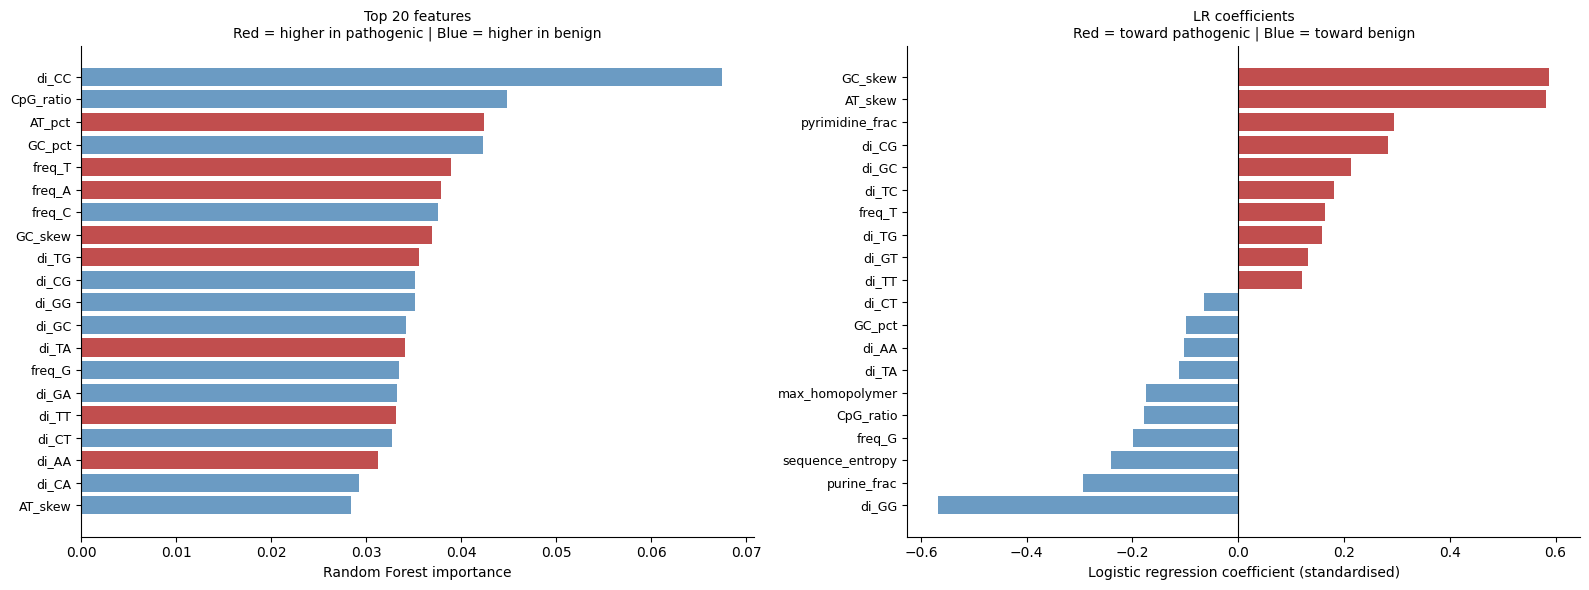

Top 5 features → pathogenic:
  GC_skew                   coef=+0.588  path=0.0131  ben=0.0065
  AT_skew                   coef=+0.582  path=-0.0123  ben=-0.0010
  pyrimidine_frac           coef=+0.294  path=0.5020  ben=0.4975
  di_CG                     coef=+0.283  path=0.0181  ben=0.0292
  di_GC                     coef=+0.214  path=0.0487  ben=0.0653

Top 5 features → benign:
  di_GG                     coef=-0.568  path=0.0569  ben=0.0826
  purine_frac               coef=-0.294  path=0.4980  ben=0.5025
  sequence_entropy          coef=-0.240  path=1.9389  ben=1.9426
  freq_G                    coef=-0.199  path=0.2195  ben=0.2594
  CpG_ratio                 coef=-0.179  path=0.2939  ben=0.3578


In [ ]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_scaled, y)
coefs = pd.Series(lr.coef_[0], index=feature_cols).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
top20  = importances.head(20)
colors = ['firebrick' if results_df[results_df['feature']==f]['difference'].values[0] > 0
          else 'steelblue' for f in top20.index]
ax.barh(range(len(top20)), top20.values[::-1], color=colors[::-1], alpha=0.8)
ax.set_yticks(range(len(top20))); ax.set_yticklabels(top20.index[::-1], fontsize=9)
ax.set_xlabel('Random Forest importance')
ax.set_title('Top 20 features\nRed = higher in pathogenic | Blue = higher in benign', fontsize=10)
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
top_coefs = pd.concat([coefs.head(10), coefs.tail(10)]).sort_values()
bar_colors = ['firebrick' if v > 0 else 'steelblue' for v in top_coefs.values]
ax.barh(range(len(top_coefs)), top_coefs.values, color=bar_colors, alpha=0.8)
ax.set_yticks(range(len(top_coefs))); ax.set_yticklabels(top_coefs.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic regression coefficient (standardised)')
ax.set_title('LR coefficients\nRed = toward pathogenic | Blue = toward benign', fontsize=10)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/feature_importance_day13.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features → pathogenic:')
for feat, coef in coefs.tail(5)[::-1].items():
    row = results_df[results_df['feature']==feat].iloc[0]
    print(f'  {feat:<25} coef={coef:+.3f}  path={row["path_mean"]:.4f}  ben={row["ben_mean"]:.4f}')

print('\nTop 5 features → benign:')
for feat, coef in coefs.head(5).items():
    row = results_df[results_df['feature']==feat].iloc[0]
    print(f'  {feat:<25} coef={coef:+.3f}  path={row["path_mean"]:.4f}  ben={row["ben_mean"]:.4f}')

In [ ]:
import pickle

save_data = {'feat_df': feat_df, 'results_df': results_df,
             'feature_cols': feature_cols, 'sig_features': sig_features,
             'path_seqs': path_seqs, 'ben_seqs': ben_seqs}

save_path = '/content/drive/MyDrive/project-finetuned/day13_composition_results.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(save_data, f)
print(f'Saved: {save_path}')

print()
print('═' * 55)
print('DAY 13 COMPLETE')
print('═' * 55)
print(f'Significant features (Bonferroni): {len(sig_features)}')
print(f'Best composition F1:               {max(all_f1s):.3f}')
print(f'DNABERT-2 F1:                      0.783')
print(f'Gap:                               {0.783 - max(all_f1s):.3f}')

Saved: /content/drive/MyDrive/project-finetuned/day13_composition_results.pkl

═══════════════════════════════════════════════════════
DAY 13 COMPLETE
═══════════════════════════════════════════════════════
Significant features (Bonferroni): 14
Best composition F1:               0.669
DNABERT-2 F1:                      0.783
Gap:                               0.114
